In [1]:
# PRODIGY_DS_02
# Data Cleaning and Exploratory Data Analysis (EDA)
# Titanic Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Titanic dataset

df = pd.read_csv('/content/train.csv')

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

Dataset loaded successfully!
Shape of dataset: (891, 12)


In [3]:
# Display the first 5 rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Check dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Statistical summary

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Check number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 891
Number of columns: 12


In [7]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
# STEP 8: Data Cleaning

# Create a copy of the original dataset
cleaned_df = df.copy()

# Fill missing Age values with the median age
cleaned_df['Age'] = cleaned_df['Age'].fillna(cleaned_df['Age'].median())

# Fill missing Embarked values with the most frequent value
cleaned_df['Embarked'] = cleaned_df['Embarked'].fillna(
    cleaned_df['Embarked'].mode()[0]
)

# Remove Cabin because most of its values are missing
cleaned_df.drop('Cabin', axis=1, inplace=True)

print("Data cleaning completed successfully!")

Data cleaning completed successfully!


In [9]:
# Check missing values after cleaning

print("Missing values after cleaning:")
print(cleaned_df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [10]:
# Check the cleaned dataset

print("Shape of cleaned dataset:", cleaned_df.shape)
cleaned_df.head()

Shape of cleaned dataset: (891, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [11]:
# Save the cleaned dataset

cleaned_df.to_csv('/content/cleaned_titanic.csv', index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


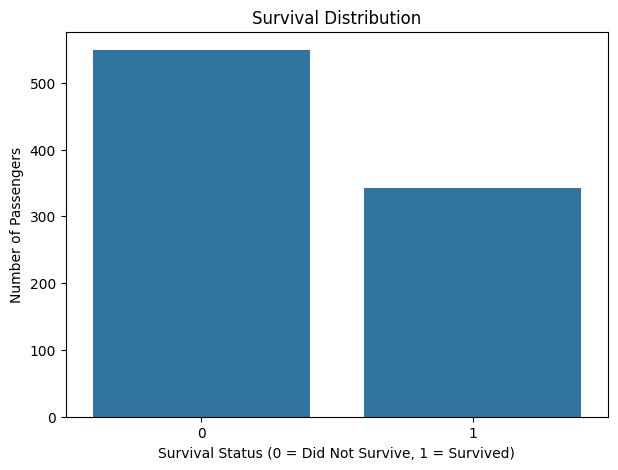

In [12]:
# STEP 11: Survival Distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=cleaned_df, x='Survived')

plt.title('Survival Distribution')
plt.xlabel('Survival Status (0 = Did Not Survive, 1 = Survived)')
plt.ylabel('Number of Passengers')

plt.show()

In [13]:
# Number of passengers who survived and did not survive

survival_counts = cleaned_df['Survived'].value_counts()

print("Passengers who did not survive:", survival_counts[0])
print("Passengers who survived:", survival_counts[1])

Passengers who did not survive: 549
Passengers who survived: 342


In [14]:
# Overall survival percentage

survival_rate = cleaned_df['Survived'].mean() * 100

print(f"Overall survival rate: {survival_rate:.2f}%")

Overall survival rate: 38.38%


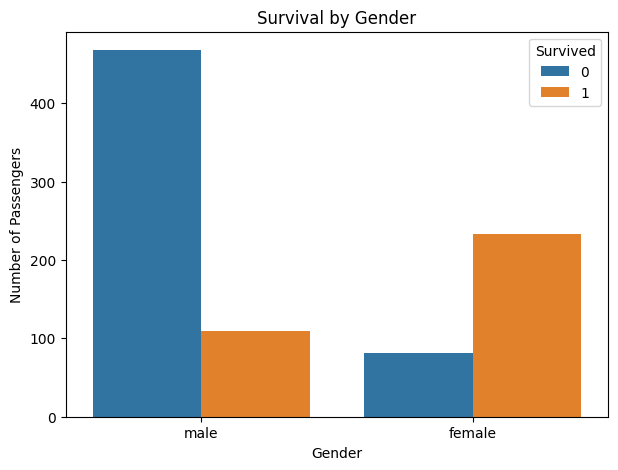

In [15]:
# STEP 13: Survival by Gender

plt.figure(figsize=(7, 5))

sns.countplot(data=cleaned_df, x='Sex', hue='Survived')

plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.show()

In [16]:
# Survival rate by gender

gender_survival = cleaned_df.groupby('Sex')['Survived'].mean() * 100

print("Survival rate by gender:")
print(gender_survival)

Survival rate by gender:
Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


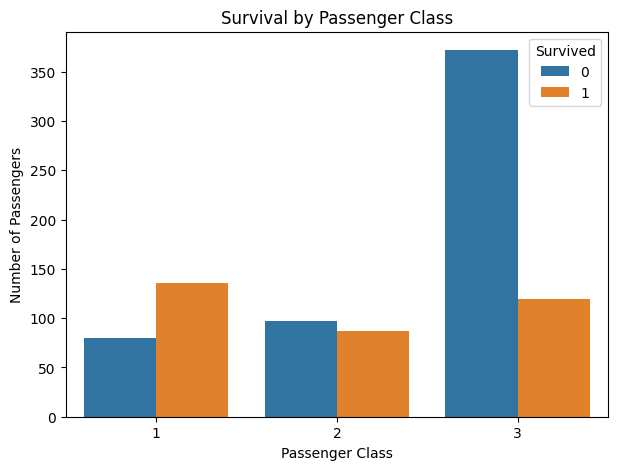

In [17]:
# STEP 14: Survival by Passenger Class

plt.figure(figsize=(7, 5))

sns.countplot(data=cleaned_df, x='Pclass', hue='Survived')

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

plt.show()

In [18]:
# Survival rate by passenger class

class_survival = cleaned_df.groupby('Pclass')['Survived'].mean() * 100

print("Survival rate by passenger class:")
print(class_survival)

Survival rate by passenger class:
Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


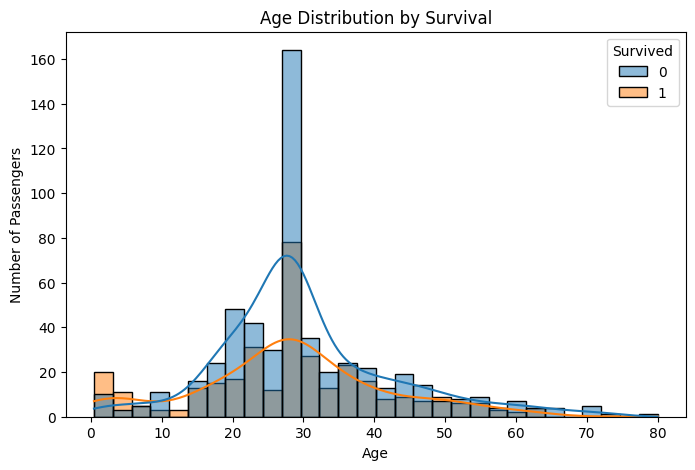

In [19]:
# STEP 15: Age Distribution

plt.figure(figsize=(8, 5))

sns.histplot(data=cleaned_df, x='Age', hue='Survived', kde=True)

plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')

plt.show()

In [20]:
# Create age groups

cleaned_df['AgeGroup'] = pd.cut(
    cleaned_df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']
)

age_survival = cleaned_df.groupby(
    'AgeGroup', observed=False
)['Survived'].mean() * 100

print("Survival rate by age group:")
print(age_survival)

Survival rate by age group:
AgeGroup
Child          57.971014
Teenager       42.857143
Young Adult    35.327103
Adult          40.000000
Senior         22.727273
Name: Survived, dtype: float64


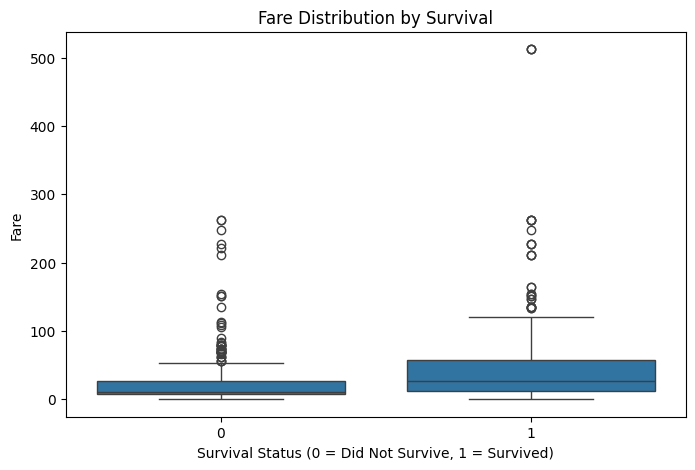

In [21]:
# STEP 16: Fare Distribution by Survival

plt.figure(figsize=(8, 5))

sns.boxplot(data=cleaned_df, x='Survived', y='Fare')

plt.title('Fare Distribution by Survival')
plt.xlabel('Survival Status (0 = Did Not Survive, 1 = Survived)')
plt.ylabel('Fare')

plt.show()

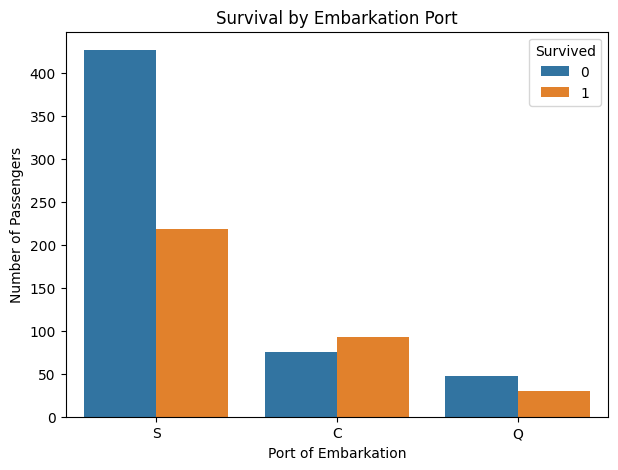

In [22]:
# STEP 17: Survival by Embarkation Port

plt.figure(figsize=(7, 5))

sns.countplot(data=cleaned_df, x='Embarked', hue='Survived')

plt.title('Survival by Embarkation Port')
plt.xlabel('Port of Embarkation')
plt.ylabel('Number of Passengers')

plt.show()

In [23]:
# Survival rate by embarkation port

embarked_survival = cleaned_df.groupby('Embarked')['Survived'].mean() * 100

print("Survival rate by embarkation port:")
print(embarked_survival)

Survival rate by embarkation port:
Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


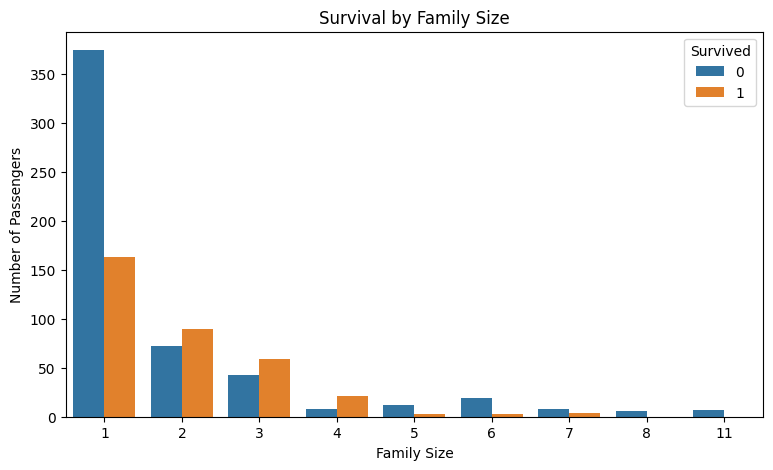

In [24]:
# STEP 18: Create Family Size

cleaned_df['FamilySize'] = cleaned_df['SibSp'] + cleaned_df['Parch'] + 1

plt.figure(figsize=(9, 5))

sns.countplot(data=cleaned_df, x='FamilySize', hue='Survived')

plt.title('Survival by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Number of Passengers')

plt.show()

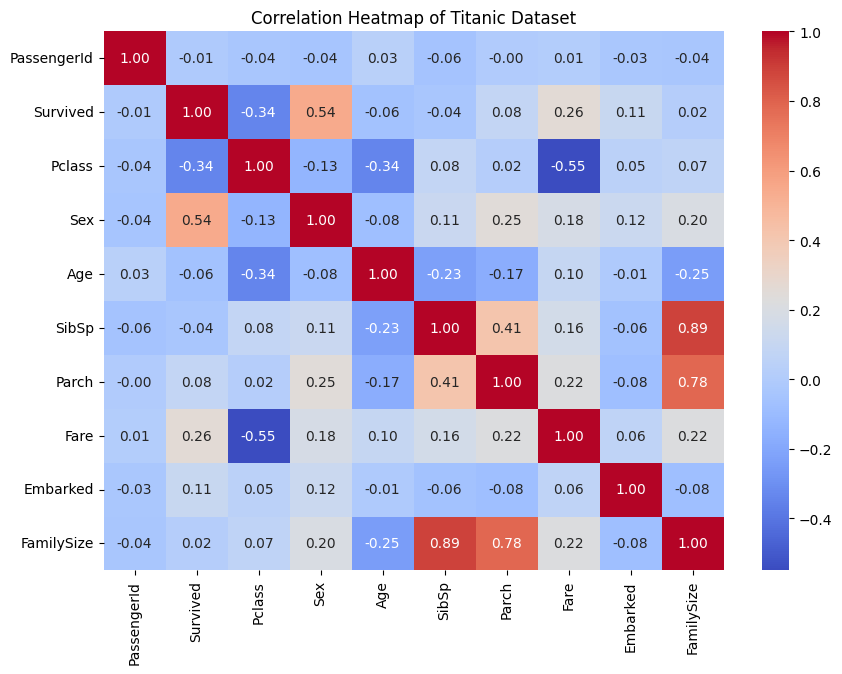

In [25]:
# STEP 19: Correlation Heatmap

correlation_df = cleaned_df.copy()

# Convert categorical variables into numerical values
correlation_df['Sex'] = correlation_df['Sex'].map({
    'male': 0,
    'female': 1
})

correlation_df['Embarked'] = correlation_df['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

# Select numerical columns
numeric_df = correlation_df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Titanic Dataset')

plt.show()

# PRODIGY_DS_02 - Data Cleaning and Exploratory Data Analysis

## Introduction

This project focuses on performing data cleaning and exploratory data analysis (EDA) on the Titanic dataset. The objective is to explore the relationships between different passenger characteristics and survival outcomes, and to identify important patterns and trends in the data.

The analysis was performed using Python, Pandas, NumPy, Matplotlib, and Seaborn.

## Dataset Description

The Titanic dataset contains information about passengers who travelled on the RMS Titanic.

The dataset includes variables such as passenger class, gender, age, number of siblings or spouses aboard, number of parents or children aboard, ticket information, fare, cabin, port of embarkation, and survival status.

The target variable is Survived:
- 0 = Did not survive
- 1 = Survived

## Data Cleaning

The dataset was examined for missing values and inconsistencies.

The following cleaning steps were performed:

- Missing values in the Age column were replaced using the median age.
- Missing values in the Embarked column were replaced using the most frequent value.
- The Cabin column was removed because it contained a large number of missing values.
- The cleaned dataset was checked again to ensure that the missing values were handled properly.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the distribution of the data and identify relationships between passenger characteristics and survival.

The analysis included:

- Overall survival distribution
- Survival by gender
- Survival by passenger class
- Age distribution and survival
- Fare distribution and survival
- Survival by embarkation port
- Survival by family size
- Correlation analysis

## Key Findings

- The overall survival rate was approximately 38.38%.
- Female passengers had a considerably higher survival rate than male passengers.
- First-class passengers generally had a higher survival rate than second- and third-class passengers.
- Third-class passengers had the highest number of deaths.
- Age showed different survival patterns across different age groups.
- Passengers who paid higher fares generally had better survival outcomes.
- Survival rates varied across the different embarkation ports.
- Family size also showed a relationship with passenger survival.
- Gender and passenger class were among the most noticeable factors associated with survival.

## Conclusion

The Titanic dataset was successfully cleaned and analyzed using Python.

The analysis demonstrated how data cleaning and exploratory data analysis can be used to identify meaningful patterns in a real-world dataset. The results showed that factors such as gender, passenger class, age, fare, embarkation port, and family size were associated with survival outcomes.

Female passengers and passengers travelling in higher classes generally had better chances of survival. Data visualization helped in understanding these relationships and trends more clearly.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [26]:
# Save the final cleaned dataset

cleaned_df.to_csv('/content/cleaned_titanic.csv', index=False)

print("Final cleaned dataset saved successfully!")

Final cleaned dataset saved successfully!
